# Libraries

In [8]:
from _utils import *
from _regex_functions import *

# Import Data

In [9]:
raw_excel_df = pd.read_excel(ANNOTATIONS_FP)

keep_cols = ['row_id', 'file_hash', 'type','subtype_1','subtype_confidence','notes_free_text','label']

ant_df = raw_excel_df \
    .query("annotated == 'y'") \
    .query("type != 'Exclude'") \
    .query("type != 'I Multi'") \
    .query("type != 'R Multi'") \
    .query("type != 'I Cl'") \
    .query("type != 'Neither'") \
    .query("subtype_confidence != '1 - Not confident at all'") \
    .assign(
        label=lambda df: df.apply(
            lambda r: map_subtype(r.type, r.subtype_1),
            axis=1
        )
    ) \
    .query("label != 'R Other (Rare)'") \
    .loc[:, keep_cols]

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed


In [10]:
ant_df.shape

(827, 7)

In [11]:
raw_gpt_df = pd.read_csv(RAW_DATA_DIR / "mod_files_gpt.csv")

raw_gpt_df = pd.read_csv(RAW_DATA_DIR / "mod_files_gpt.csv").rename(columns={"hash":"file_hash"})
ANNOTATED_SAMPLES = ant_df["file_hash"].tolist()

In [12]:
raw_gpt_df = pd.read_csv(RAW_DATA_DIR / "mod_files_gpt.csv").rename(columns={"hash":"file_hash"})
raw_gpt_df.head()

,file_hash,currents1,notes1,currents2,notes2,currents3,notes3,currents_at_least_1,currents_at_least_2,currents_at_least_3
0,cf53b079807fc6711d9563031aae227dd1a73cf5add973...,"[""IK Skca""]",This model uses a Hill function to represent t...,"[""IK Skca""]",This model uses a Hill equation to describe th...,"[""IK Skca""]",This model uses a Hill function to describe th...,"[""IK Skca""]","[""IK Skca""]","[""IK Skca""]"
1,04c32cd101754ad7f2eaf278919c6ce85b8a7d67149fca...,"[""I Sodium"", ""I Potassium"", ""I Calcium"", ""NMDA""]",Incorporates dependencies on extracellular pot...,"[""I Potassium"", ""I Sodium"", ""I Calcium"", ""NMDA""]",The model directly writes ion currents instead...,"[""I Potassium"", ""I Sodium"", ""I Calcium"", ""NMDA""]",This model includes direct calculation of ion ...,"[""I Potassium"", ""I Calcium"", ""NMDA"", ""I Sodium""]","[""I Potassium"", ""I Calcium"", ""NMDA"", ""I Sodium""]","[""I Potassium"", ""I Calcium"", ""NMDA"", ""I Sodium""]"
2,2d3c5c121271cfad6d2e35db7d2c418de64f97e57c20a0...,"[""I T low threshold""]",The model uses the GHK equation for calculatin...,"[""I T low threshold""]",The model is based on work by Huguenard and Mc...,"[""I T low threshold""]",Uses a GHK equation for calculating the calciu...,"[""I T low threshold""]","[""I T low threshold""]","[""I T low threshold""]"
3,e2f71ea16f8378b3cf0670f9bd5e457634824ab9ee8a7c...,"[""I K""]",The model includes two gating variables each w...,"[""I K""]",Model implements a potassium delayed rectifier...,"[""I K""]",The model uses two-state gating kinetics. Some...,"[""I K""]","[""I K""]","[""I K""]"
4,04860f65d331d381e779e488566f95ab0e1fa4960b50a7...,"[""I Sodium""]",Includes frequency calculation and spike detec...,"[""I Na,t""]",Includes additional parameters for shift and s...,"[""I Na,t""]",Includes custom procedures for spike frequency...,"[""I Sodium"", ""I Na,t""]","[""I Na,t""]",[]


In [13]:

gpt_df = raw_gpt_df \
    .apply(summarize_predictions, axis=1) \
    .query("file_hash in @ANNOTATED_SAMPLES") \
    .assign(
        gpt_pred=lambda df: df["gpt_pred"].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ),
        gpt_pred_count=lambda df: df["gpt_pred"].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        ),
        gpt_pred_adj=lambda df: df.apply(adjust_gpt_pred, axis=1),
        gpt_pred_subtype_label=lambda df: df["gpt_pred_adj"].apply(map_gpt_subtype),
        gpt_pred_type_label=lambda df: df["gpt_pred_subtype_label"].apply(map_type)
    ) \
    .loc[:, [
        "file_hash",
        "gpt_pred",
        "gpt_pred_count",
        "gpt_confidence",
        "gpt_pred_adj",
        "gpt_pred_subtype_label",
        "gpt_pred_type_label"
    ]]


In [14]:
combined_df = pd.read_csv(PIPELINE_DATA_DIR / "sim_features_combined.csv")

In [15]:
sim_df = (
    combined_df
    .drop_duplicates(subset="mod_file")
    .rename(columns=lambda col: col if col in ['mod_file', 'mod_name'] else f"{col}_simfeat")
    .assign(file_hash=lambda df: df['mod_file'].str.replace(r'\.mod$', '', regex=True))
    .drop(columns=["suffix_simfeat","source_file_simfeat","source_folder_simfeat"])
    .reset_index(drop=True)
)

In [16]:
sim_df.shape

(749, 43)

In [17]:
json_df = pd.read_json(JSON_FP)

In [18]:
json_df.head()

,row_id,file_hash,raw_sha,count,url,model_id,created_date,download_url,filename,content,error_code,has_include,download_inc_url,has_h_url,download_h_url,download_date
0,1,f8be35d0c20d1b1f3de4c44323e1780ee24f06893b6364...,67b75245b9690ce219f34a5905425672dcb5c0661a885f...,6,https://modeldb.science/183300?tab=2&file=Shor...,183300,2015-07-14T12:32:07.383,https://modeldb.science/getModelFile?model=183...,ShortEtAl2016/NaP.mod,TITLE Sodium persistent current\n\nCOMMENT\n ...,None,0,[],0,[],2025-12-07 06:41:59
1,2,e97ca8a7f9734805832e5ae75442d19d3d7796b9a24190...,b45c13164f1eeaf4ba61ee8522304f7382fa0541831b1a...,1,https://modeldb.science/223649?tab=2&file=Altu...,223649,2017-01-24T12:13:31.987,https://modeldb.science/getModelFile?model=223...,AlturkiEtAl2016/1_Hemond/Segregated/kaprox.mod,TITLE K-A channel from Klee Ficker and Heinema...,None,0,[],0,[],2025-12-07 06:41:59
2,3,b428f4a84f4302dd5e9139beb678039621e4ee5e88b780...,b720bf29848dde82785dd101105f185ebcf9affa081dfd...,1,https://modeldb.science/3511?tab=2&file=mcn1/m...,3511,2002-01-08T13:56:14,https://modeldb.science/getModelFile?model=351...,mcn1/mcn1_lg.mod,INDEPENDENT {t FROM 0 TO 1 WITH 1 (ms)}\n\nNEU...,None,0,[],0,[],2025-12-07 06:41:59
3,4,606423f8f4a4f406f3387c7ee6f142bd121237272c347d...,81645a02d4dbf324cf8b82e8f31bda2ce46c3753f7a8ac...,1,https://modeldb.science/262115?tab=2&file=demo...,262115,2020-02-24T19:04:46.75,https://modeldb.science/getModelFile?model=262...,demo_destexhe-pare-1999/multiGABAa.mod,TITLE multiple GABAa receptors\n\nCOMMENT\n---...,None,0,[],0,[],2025-12-07 06:42:00
4,5,99713c0032634e96cc7cde2dce02d8aa2baf75ad4cc835...,5fe32f050754f534d60c7c126ecd805216089cd0594062...,1,https://modeldb.science/150288?tab=2&file=KimE...,150288,2013-07-19T19:09:32,https://modeldb.science/getModelFile?model=150...,KimEtAl2013/interV2pyrDDANE_STFD.mod,:Interneuron Cells to Pyramidal Cells GABA wit...,None,0,[],0,[],2025-12-07 06:42:00


# Feature Engineering

In [19]:
# Regex patterns (non-capturing; match at line start with MULTILINE)
pattern_any = r'^\s*(?:INCLUDE\s+"[^"]+"|#include\s*[<"][^">]+[>"])'
pattern_cap = r'^\s*(?:INCLUDE\s+"[^"]+")'

# json_df2 build
json_df2 = (
    json_df
    .merge(ant_df, on=["row_id", "file_hash"], how="inner")
    .assign(
        mod_name = lambda df: df["url"].apply(get_fname),
        suffix = lambda df: df["content"].apply(get_suffix),
        read_ion = lambda df: df["content"].apply(get_read_ion),
        read_ion2 = lambda df: df["read_ion"].apply(
            lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []
        ),
        write_ion = lambda df: df["content"].apply(get_write_ion),
        write_ion2 = lambda df: df["write_ion"].apply(
            lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []
        ),
        parameter = lambda df: df["content"].apply(get_parameter),
        state = lambda df: df["content"].apply(get_derivative),
        net_receive = lambda df: df["content"].apply(get_net_receive),
        point_process = lambda df: df["content"].apply(get_point_process),
        nonspecific_current = lambda df: df["content"].apply(get_nonspecific_current),
         parameter_yn = lambda df: df["parameter"].apply(
            lambda x: 1 if isinstance(x, dict) and len(x) > 0 else (1 if pd.notna(x) and not isinstance(x, dict) else 0)
        ),
        state_yn = lambda df: df["state"].apply(
            lambda x: 1 if isinstance(x, (list, int)) and (len(x) > 0 if isinstance(x, list) else x > 0) else (1 if pd.notna(x) and not isinstance(x, (list, int)) else 0)
        ),

        
        states_count = lambda df: df["state"].apply(lambda x: len(x) if isinstance(x, list) else 0),
        clamp_yn = lambda df: df.apply(lambda row: has_electrode_or_clamp(row["mod_name"], row["content"]), axis=1),
        suffix_yn = lambda df: df["suffix"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (0 if pd.isna(x) or x == "none" else 1)
        ),
        point_process_yn = lambda df: df["point_process"].apply(lambda x: 1 if pd.notna(x) else 0),
        net_receive_yn = lambda df: df["net_receive"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)
        ),
        i_nonspecific_yn = lambda df: df["nonspecific_current"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)
        ),
        not_ion_channel_yn = lambda df: (
            (df["suffix_yn"] == 0) & df["read_ion"].isna() & df["write_ion"].isna() & df["nonspecific_current"].isna()
        ).astype(int),
        not_receptor_yn = lambda df: (
            (df["point_process_yn"] == 0) & (df["net_receive_yn"] == 0)
        ).astype(int),

        mg_yn = lambda df: df["content"].apply(has_mg),
        verbatim_yn = lambda df: df["content"].apply(has_verbatim),
        verbatim_count = lambda df: df["content"].apply(get_verbatim_length),
        pointer_yn = lambda df: df["content"].apply(has_pointer),




        # Include indicators and line counts
        include_yn = lambda df: df['content'].str.contains(pattern_any, case=False, na=False, flags=re.MULTILINE),
        include_cap_yn = lambda df: df['content'].str.contains(pattern_cap, case=True, na=False, flags=re.MULTILINE)

    )
    .reset_index(drop=True)
)


In [20]:
#View(json_df2[["pointer_yn","url"]].sort_values("pointer_yn", ascending=False).head())

In [21]:
#View(json_df2[["url","has_verbatim_yn","verbatim_count"]].query("has_verbatim_yn ==1").sort_values("verbatim_count", ascending=False))

In [22]:
# Use MultiLabelBinarizer separately for read and write ions
# Reset index before merging to avoid index mismatches
mlb_read = MultiLabelBinarizer()
read_df = pd.DataFrame(mlb_read.fit_transform(json_df2['read_ion2']), 
                                columns=[f'read_{col}_yn' for col in mlb_read.classes_]).reset_index(drop=True)

mlb_write = MultiLabelBinarizer()
write_df = pd.DataFrame(mlb_write.fit_transform(json_df2['write_ion2']), 
                                 columns=[f'write_{col}_yn' for col in mlb_write.classes_]).reset_index(drop=True)

In [23]:
json_df3 = json_df2.drop(columns=['read_ion2', 'write_ion2']).join(read_df, rsuffix='_read_dup').join(write_df, rsuffix='_write_dup').dropna(subset=["label"])

In [24]:
#json_df3["created_year"] = pd.to_datetime(json_df3["created_date"], errors='coerce').dt.year
#print(json_df3["created_year"].agg(['min', 'max', 'mean']))

In [25]:
#Number of mod files in sample that have features derived from simulation
json_df3.merge(sim_df, how="inner", on="file_hash").shape[0]

575

In [26]:
json_df4 = json_df3.merge(sim_df, how="left", on="file_hash")

In [27]:
EXTERNAL_VALIDATION_SET = json_df4.query("row_id > 1000")["file_hash"].tolist()

In [28]:
print("Total shape", json_df4.shape)
print("Total unique currents/receptors", json_df4["row_id"].nunique())

Total shape (827, 111)
Total unique currents/receptors 827


In [29]:
df_pre = json_df4.set_index('file_hash').filter(regex=r'(_yn|_count|label|type|volt_min|volt_max|_simfeat)$')

In [30]:
df_pre.shape

(827, 82)

In [31]:
df_pre["type"].value_counts()

type
I K         334
I Na        152
Receptor    134
I Ca        124
I H          47
I Other      36
Name: count, dtype: int64

In [32]:
df_pre["label"].value_counts()

label
I K (A-type)                95
I Na (Transient)            87
I K (Delayed Rectifier)     82
I Ca (HVA)                  78
I K (Ca-activated)          69
I K (Rare)                  48
I H                         47
R Glutamate (NMDA)          42
I K (M-type)                40
R GABA                      37
R Glutamate (AMPA)          36
I Other (Rare)              36
I Ca (T-type LT)            32
I Na (Rare)                 24
I Na (Persistent)           22
R Other (General)           19
I Na (Slow inactivation)    19
I Ca (Rare)                 14
Name: count, dtype: int64

In [33]:
df_pre.to_csv(DATA_DIR / "pipeline/preprocessed.csv")

## Splitting into Train and Test Sets

In [34]:

def clean_numeric_columns(df):
    """Clean column names and enforce numeric dtype for object columns."""
    df = df.copy()
    df.columns = df.columns.astype(str).str.replace(r"[\[\]<>]", "_", regex=True)
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="raise")
    return df

def encode_labels(train_s, test_s):
    """Fit a LabelEncoder on train_s and transform both train/test (as strings)."""
    le = LabelEncoder().fit(pd.Series(train_s).astype(str))
    y_tr = le.transform(pd.Series(train_s).astype(str))
    y_te = le.transform(pd.Series(test_s).astype(str))
    return le, y_tr, y_te

def plot_confusion(y_true, y_pred, labels, title, normalize=None, figsize=(10, 7)):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


def xgb_gain_importance(estimator, feature_names):
    """Return gain-based importances mapped to real feature names as a sorted Series."""
    booster = estimator.get_booster()
    score = booster.get_score(importance_type="gain")  # dict: {key -> gain}
    mapped = {}
    for k, v in score.items():
        if isinstance(k, str) and k.startswith('f') and k[1:].isdigit():
            idx = int(k[1:])
            name = feature_names[idx] if idx < len(feature_names) else k
        else:
            name = k
        mapped[name] = float(v)
    s = pd.Series(mapped, dtype=float)
    s = s.reindex(feature_names).fillna(0.0).sort_values(ascending=False)
    return s

def plot_top_features(imp_series, title, topn=15, figsize=(9, 6)):
    top = imp_series.head(topn)[::-1]
    plt.figure(figsize=figsize)
    top.plot.barh()
    plt.title(title); plt.xlabel("Gain importance"); plt.ylabel("Feature")
    plt.tight_layout(); plt.show()

In [35]:
SEED = 6
np.random.seed(SEED)

X = df_pre.drop(columns=["label","type"])
y_type = df_pre["type"].astype(str)
y_subtype = df_pre["label"].astype(str)
X_train, X_test, y_type_train, y_type_test, y_subtype_train, y_subtype_test = train_test_split(
    X, y_type, y_subtype, test_size=0.20, stratify=y_subtype, random_state=SEED
)



TRAIN_SET = X_train.index.tolist()
VAL_SET = X_test.index.tolist()

df_train = pd.DataFrame({"file_hash": TRAIN_SET, "set": "train"})
df_test  = pd.DataFrame({"file_hash": EXTERNAL_VALIDATION_SET, "set": "test"})
df_val   = pd.DataFrame({"file_hash": VAL_SET, "set": "val"})
df_split = pd.concat([df_train, df_test, df_val], ignore_index=True)
df_split.to_csv("../data/pipeline/crosswalk.csv", index=False)


## Feature Selection Pipeline (Feature-Engine)

In [36]:
# Encode subtypes for selection scoring
subtype_encoder, y_subtype_train_enc, y_subtype_test_enc = encode_labels(y_subtype_train, y_subtype_test)

# Drop columns with ≥99% missing values
threshold = 0.99
missing_fraction = X_train.isna().mean()
cols_to_drop = missing_fraction[missing_fraction >= threshold].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with ≥{int(threshold*100)}% missingness.")

X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean  = X_test.drop(columns=cols_to_drop, errors="ignore")

# Lists AFTER dropping
binary_list     = [c for c in X_train_clean.columns if c.endswith("_yn")]
continuous_list = [c for c in X_train_clean.columns if any(s in c for s in ["_min", "_max", "_simfeat"])]
discrete_list   = [c for c in X_train_clean.columns if c.endswith("_count")]

# Cast binaries to category
X_train_clean[binary_list] = X_train_clean[binary_list].astype("category")
X_test_clean[binary_list]  = X_test_clean[binary_list].astype("category")

# Preprocess pipeline (impute/scale/discretize)
feature_preprocess_pipeline = Pipeline(steps=[
    ("missing_indicator", AddMissingIndicator(variables=continuous_list)),
    ("arbitrary_number_imputer", ArbitraryNumberImputer(arbitrary_number=0, variables=discrete_list)),
    ("median_imputer", MeanMedianImputer(imputation_method="median", variables=continuous_list)),
    ("binary_imputer", CategoricalImputer(fill_value="0", variables=binary_list)),
    ("normalize", SklearnTransformerWrapper(MinMaxScaler(feature_range=(0, 1)), variables=continuous_list)),
    ("discretize", DecisionTreeDiscretiser(cv=5, scoring="roc_auc_ovr", regression=False, random_state=SEED, variables=discrete_list)),
])

X_train_pre = feature_preprocess_pipeline.fit_transform(X_train_clean, y_subtype_train_enc)
X_test_pre  = feature_preprocess_pipeline.transform(X_test_clean)

# Feature selection pipeline (same as yours)
feature_selection_pipeline = Pipeline(steps=[
    ("drop_constant", DropConstantFeatures(tol=0.99)),
    ("drop_duplicates", DropDuplicateFeatures()),
    ("correlated_features", SmartCorrelatedSelection(
        method="pearson",
        threshold=0.9,
        selection_method="model_performance",
        estimator=xgb.XGBClassifier(random_state=0),
        scoring="roc_auc_ovr"
    )),
])

X_train_selected = feature_selection_pipeline.fit_transform(X_train_pre, y_subtype_train_enc)
X_test_selected  = feature_selection_pipeline.transform(X_test_pre)

# Convert any remaining categories to ints (XGBoost safety)
for df in (X_train_selected, X_test_selected):
    cat_cols = df.select_dtypes(include="category").columns
    if len(cat_cols):
        df[cat_cols] = df[cat_cols].astype(int)

# Final matrices used by both approaches
X_train_final = X_train_selected.copy()
X_test_final  = X_test_selected.copy()


a = set(X_test)
b = set(X_test_selected)
DROPPED_FEATURES = list(a-b)
print("Dropped columns", len(DROPPED_FEATURES))

Dropping 0 columns with ≥99% missingness.


Dropped columns 18


In [37]:
DROPPED_FEATURES

['read_other_i_yn',
 'read_i_other_yn',
 'v_interval2_max_val_simfeat',
 'write_unknown_yn',
 'read_na_i_yn',
 'ik_interval2_max_val_simfeat',
 'write_i_cl_yn',
 'read_na_o_yn',
 'read_cl_i_yn',
 'ica_interval2_recovery_start_val_simfeat',
 'voltage_simfeat',
 'write_ca_i_yn',
 'read_other_o_yn',
 'read_cl_o_yn',
 'ina_interval2_max_val_simfeat',
 'v_interval1_min_val_simfeat',
 'v_interval1_time_to_90_min_simfeat',
 'clamp_yn']

In [38]:
# Features as rows
feature_dd = pd.DataFrame(df_pre.columns, columns=["feature"]).reset_index(drop=True)
feature_dd["dropped"] = feature_dd["feature"].isin(DROPPED_FEATURES)
feature_dd.to_csv("../data/pipeline/feature_dd.csv", index=False)

# XGB Confusion Matrix 

Fitting 50 folds for each of 40 candidates, totalling 2000 fits


[Reverse] Best CV accuracy: 0.6776
[Reverse] Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.5}

=== Held-Out Evaluation (Reverse: subtype->type) ===
Type Accuracy (derived from subtype): 0.9518072289156626

Subtype Accuracy (overall): 0.6506024096385542

Subtype Classification Report (overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.82      0.88      0.85        16
             I Ca (Rare)       0.00      0.00      0.00         3
        I Ca (T-type LT)       0.83      0.83      0.83         6
                     I H       0.89      0.89      0.89         9
            I K (A-type)       0.65      0.68      0.67        19
      I K (Ca-activated)       0.92      0.86      0.89        14
 I K (Delayed Rectifier)       0.50      0.35      0.41        17
            I K (M-type)       0.40 

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


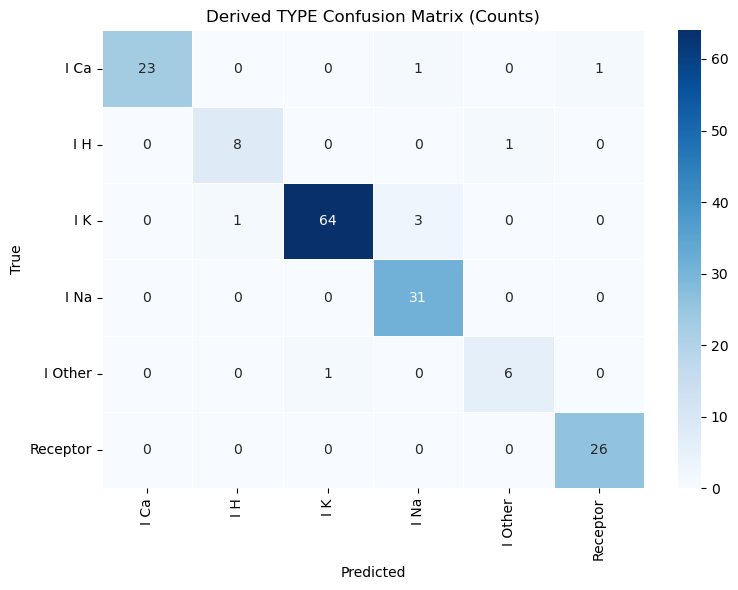

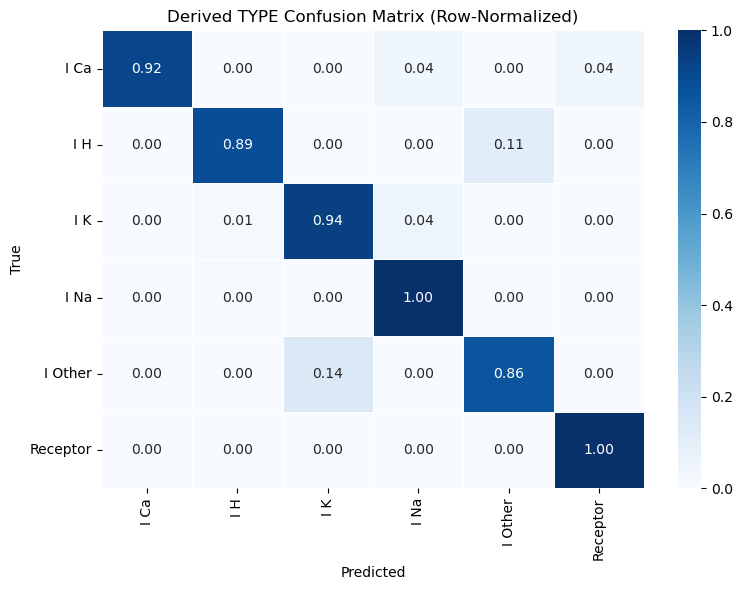

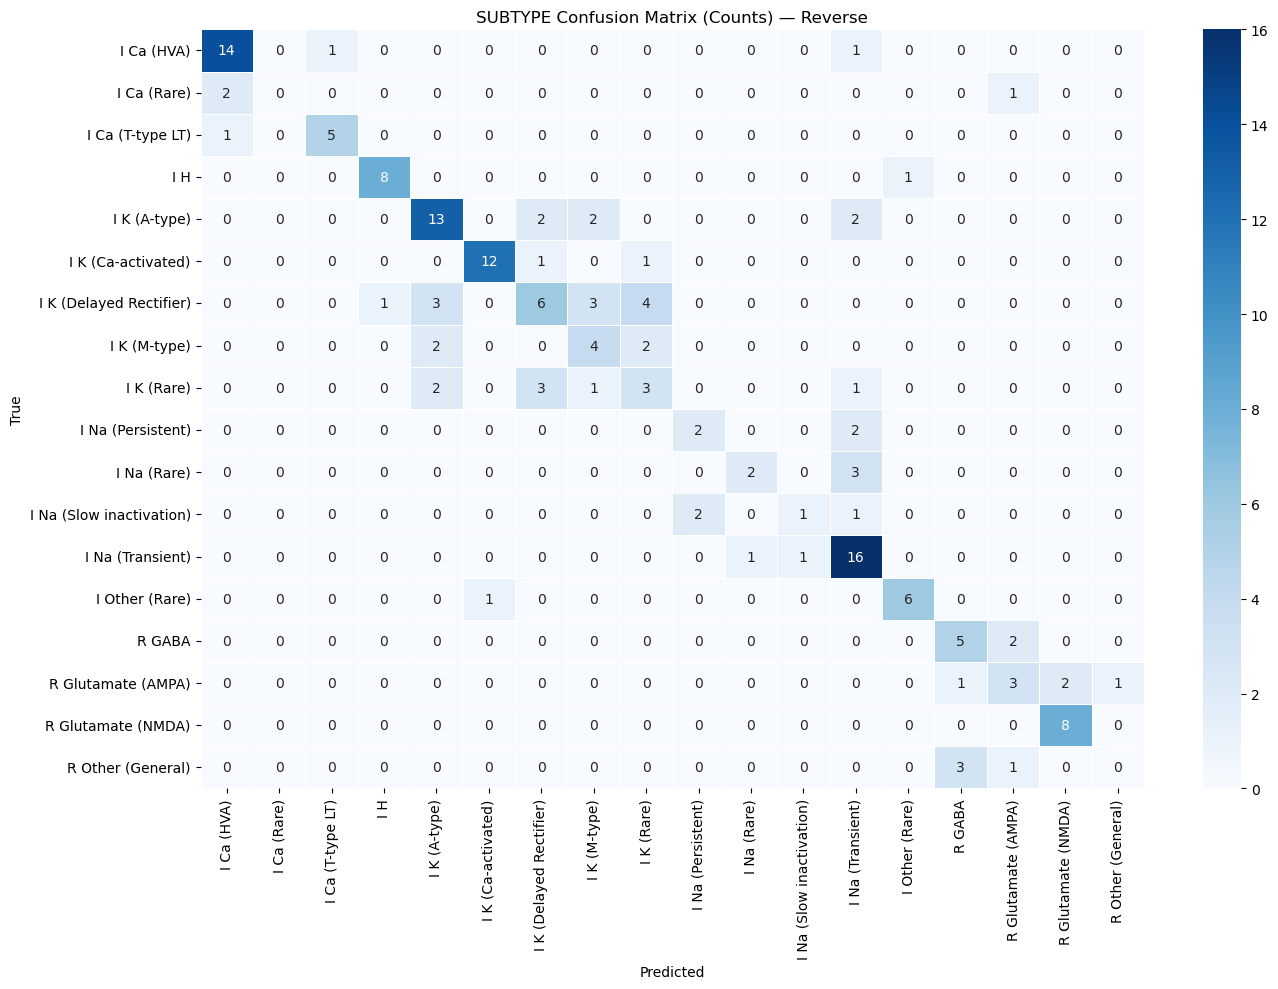

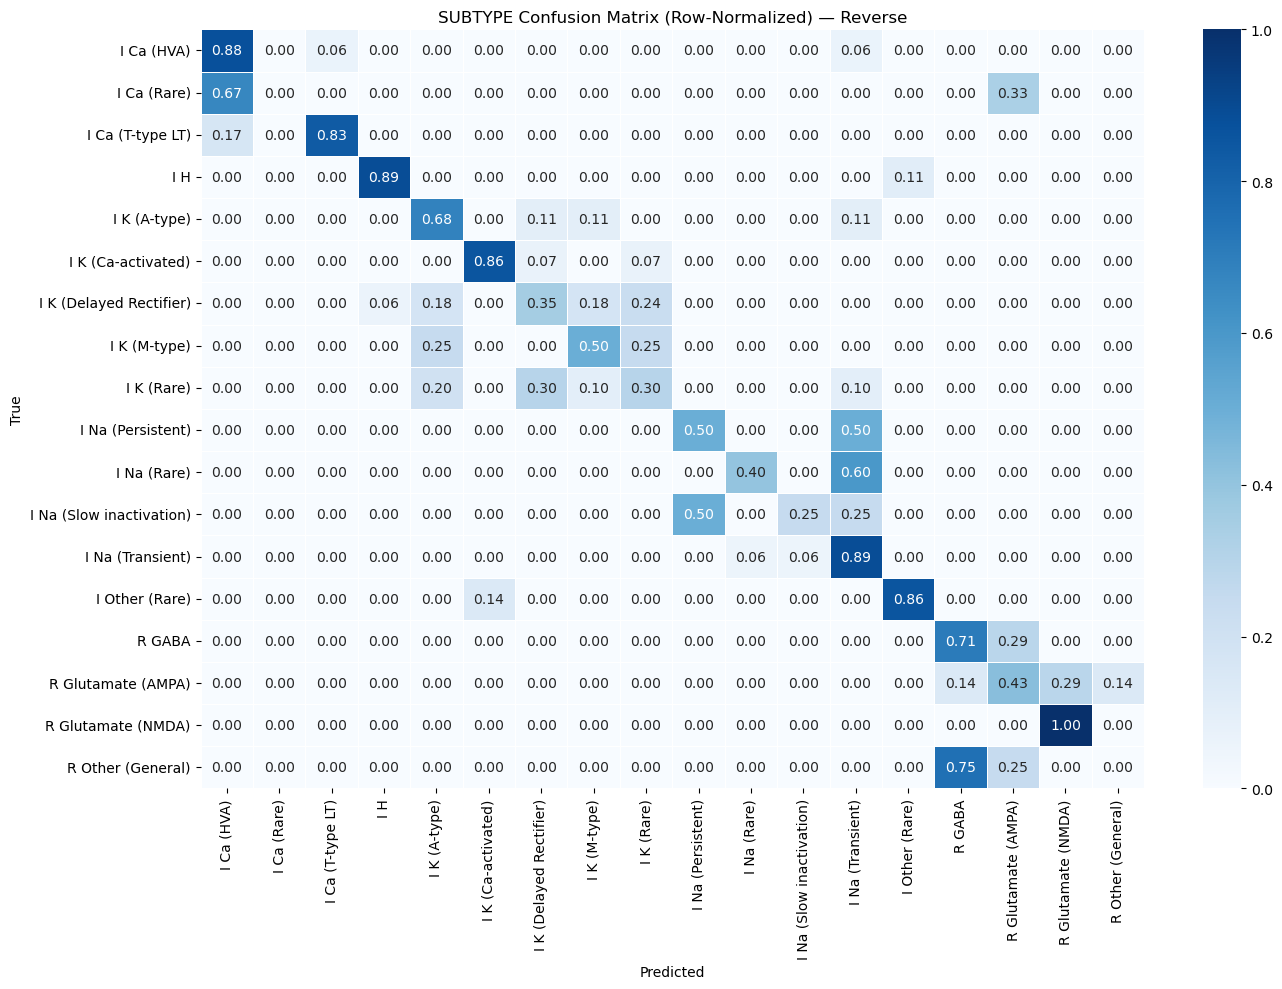

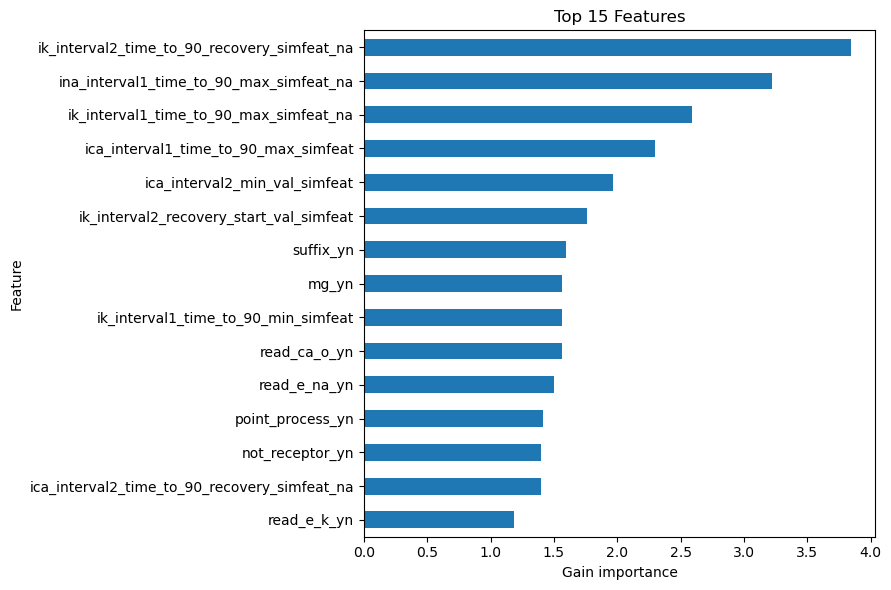

In [39]:
# --- CV splitter (yours) ---
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

# --- Base estimator ---
base_xgb = xgb.XGBClassifier(
objective="multi:softmax",
num_class=len(subtype_encoder.classes_),
eval_metric="mlogloss",
random_state=SEED,
n_jobs=1,
# optional: faster histogram algorithm if available
tree_method="hist"
)

# --- Hyperparameter search space ---
# Keep ranges modest to balance exploration vs. runtime.
param_distributions = {
"max_depth": [4, 6, 8, 10],
"learning_rate": [0.01, 0.03, 0.1, 0.2],
"n_estimators": [200, 400, 800, 1200],
"subsample": [0.6, 0.8, 1.0],
"colsample_bytree": [0.5, 0.8, 1.0],
"min_child_weight": [1, 3, 5],
"gamma": [0, 0.5, 1.0],
"reg_alpha": [0.0, 0.01, 0.1, 1.0],
"reg_lambda": [0.5, 1.0, 2.0],
}

# --- RandomizedSearchCV (uses your cv) ---
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
estimator=base_xgb,
param_distributions=param_distributions,
n_iter=40,                 # increase/decrease as needed
scoring="accuracy",
cv=cv,
random_state=SEED,
n_jobs=1,                  # keep 1 if you need strict reproducibility
refit=True,                # refit best params on full training set
verbose=1
)

# --- Run search ---
search.fit(X_train_final, y_subtype_train_enc)
print(f"[Reverse] Best CV accuracy: {search.best_score_:.4f}")
print("[Reverse] Best params:", search.best_params_)

# Best tuned model already refit on full training data
subtype_model = search.best_estimator_

# --- Predict subtype ---
y_subtype_pred_enc_rev = subtype_model.predict(X_test_final)
y_subtype_pred_rev = subtype_encoder.inverse_transform(y_subtype_pred_enc_rev)

# --- Derive TYPE from predicted subtype using lookup ---
# Create a mapping from subtype to type using your ground truth
subtype_to_type_map = ant_df[['label', 'type']].drop_duplicates().set_index('label')['type'].to_dict()

# Map XGB's predicted subtypes to their correct types
y_type_pred_rev = pd.Series(
y_subtype_pred_rev,
index=y_type_test.index
).map(subtype_to_type_map)

# --- Evaluation ---
print("\n=== Held-Out Evaluation (Reverse: subtype->type) ===")
print("Type Accuracy (derived from subtype):", accuracy_score(y_type_test, y_type_pred_rev))
print("\nSubtype Accuracy (overall):", accuracy_score(y_subtype_test, y_subtype_pred_rev))
print("\nSubtype Classification Report (overall):")
print(classification_report(y_subtype_test, y_subtype_pred_rev))

# --- Confusion matrices ---
type_labels = sorted(pd.Series(y_type_test).unique())
plot_confusion(y_type_test, y_type_pred_rev, labels=type_labels,
title="Derived TYPE Confusion Matrix (Counts)", figsize=(8, 6))
plot_confusion(y_type_test, y_type_pred_rev, labels=type_labels,
title="Derived TYPE Confusion Matrix (Row-Normalized)", normalize="true", figsize=(8, 6))

subtype_labels = sorted(pd.Series(y_subtype_test).unique())
plot_confusion(y_subtype_test, y_subtype_pred_rev, labels=subtype_labels,
title="SUBTYPE Confusion Matrix (Counts) — Reverse", figsize=(14, 10))
plot_confusion(y_subtype_test, y_subtype_pred_rev, labels=subtype_labels,
title="SUBTYPE Confusion Matrix (Row-Normalized) — Reverse", normalize="true", figsize=(14, 10))

# --- Feature importance (reverse) ---
subtype_feat_imp_rev = xgb_gain_importance(subtype_model, X_train_final.columns)
plot_top_features(subtype_feat_imp_rev, "Top 15 Features")

In [40]:
booster = subtype_model.get_booster()

gain  = booster.get_score(importance_type="gain")
cover = booster.get_score(importance_type="cover")
weight = booster.get_score(importance_type="weight")

fi_csv = pd.DataFrame({
    "feature": list(gain.keys()),
    "gain": list(gain.values()),
    "cover": [cover.get(f, 0) for f in gain.keys()],
    "weight": [weight.get(f, 0) for f in gain.keys()]
})

fi_csv.to_csv("../data/pipeline/feature_importance_global.csv", index=False)

In [41]:

# Save model (pickle)
with open("subtype_xgb_model.pkl", "wb") as f:
    pickle.dump(subtype_model, f)

# Save model (json)
subtype_model.save_model("subtype_xgb_model.json")

# Save encoder
with open("subtype_encoder.pkl", "wb") as f:
    pickle.dump(subtype_encoder, f)

# Save mapping
with open("subtype_to_type_map.pkl", "wb") as f:
    pickle.dump(subtype_to_type_map, f)

# Save feature order
with open("feature_order.json", "w") as f:
    json.dump(list(X_train_final.columns), f)


## SHAP Top Features (Overall)

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.


/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.


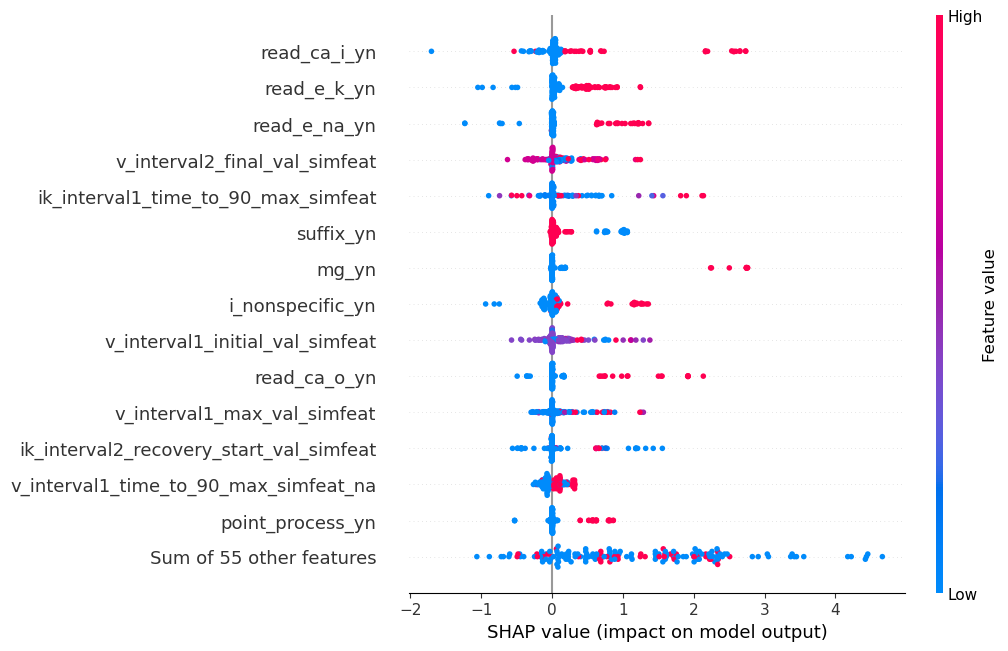

In [42]:
# Build explainer (interventional is usually best for tree models)
explainer = shap.TreeExplainer(subtype_model, feature_perturbation="interventional")

# SHAP values for test set
shap_values = explainer.shap_values(X_test_final)  # list-of-arrays (classic) OR 3D array (newer SHAP)

# Predicted class positions per row (aligns with shap_values class order)
proba = subtype_model.predict_proba(X_test_final)          # shape (n_samples, n_classes)
pred_pos = np.asarray(proba).argmax(axis=1)                # shape (n_samples,)

n_samples, n_features = X_test_final.shape

# Get per-row SHAP for the predicted class, handling both SHAP formats
if isinstance(shap_values, list):
    # shap_values[k] -> (n_samples, n_features) for class k
    shap_pred = np.vstack([shap_values[k][i] for i, k in enumerate(pred_pos)])  # (n_samples, n_features)
else:
    # shap_values -> (n_samples, n_features, n_classes)
    shap_pred = shap_values[np.arange(n_samples), :, pred_pos]                  # (n_samples, n_features)

# Pack into a dataframe
df_shap = pd.DataFrame(shap_pred, columns=X_test_final.columns)
df_shap["file_hash"] = X_test_final.index


# Compute SHAP values for all classes
explainer = shap.TreeExplainer(subtype_model, feature_perturbation="interventional")
shap_values_all = explainer(X_test_final)  # shap.Explanation, shape (n_samples, n_features, n_classes)

# Find predicted class index for each sample
proba = subtype_model.predict_proba(X_test_final)
pred_pos = np.argmax(proba, axis=1)

# Extract SHAP values for the predicted class per row
# (this converts from 3D → 2D)
shap_pred = np.array([shap_values_all.values[i, :, pred_pos[i]] for i in range(len(pred_pos))])

# Create new Explanation object for the selected SHAP values
shap_pred_expl = shap.Explanation(
    values=shap_pred,
    base_values=shap_values_all.base_values.mean(axis=1),  # average base_value across classes
    data=X_test_final,
    feature_names=X_test_final.columns
)

# --- Beeswarm plot ---
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_pred_expl, max_display=15)
plt.show()


# SHAP Top Features (By Class)

In [43]:
subtype_model.classes_


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [44]:
for i, name in enumerate(subtype_encoder.classes_):
    print(i, name)


0 I Ca (HVA)
1 I Ca (Rare)
2 I Ca (T-type LT)
3 I H
4 I K (A-type)
5 I K (Ca-activated)
6 I K (Delayed Rectifier)
7 I K (M-type)
8 I K (Rare)
9 I Na (Persistent)
10 I Na (Rare)
11 I Na (Slow inactivation)
12 I Na (Transient)
13 I Other (Rare)
14 R GABA
15 R Glutamate (AMPA)
16 R Glutamate (NMDA)
17 R Other (General)


SHAP beeswarm — class 0: I Ca (HVA)


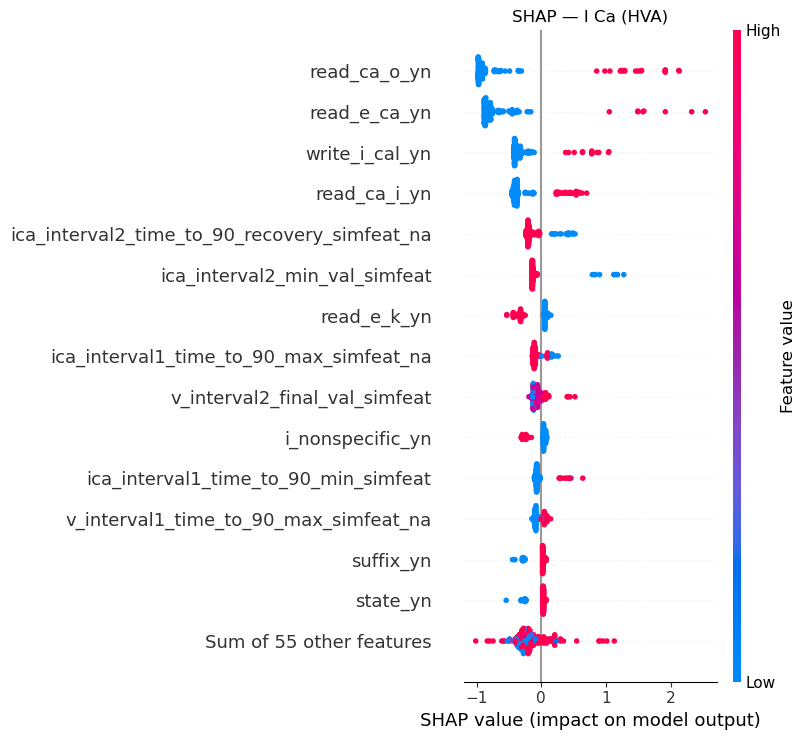

SHAP beeswarm — class 1: I Ca (Rare)


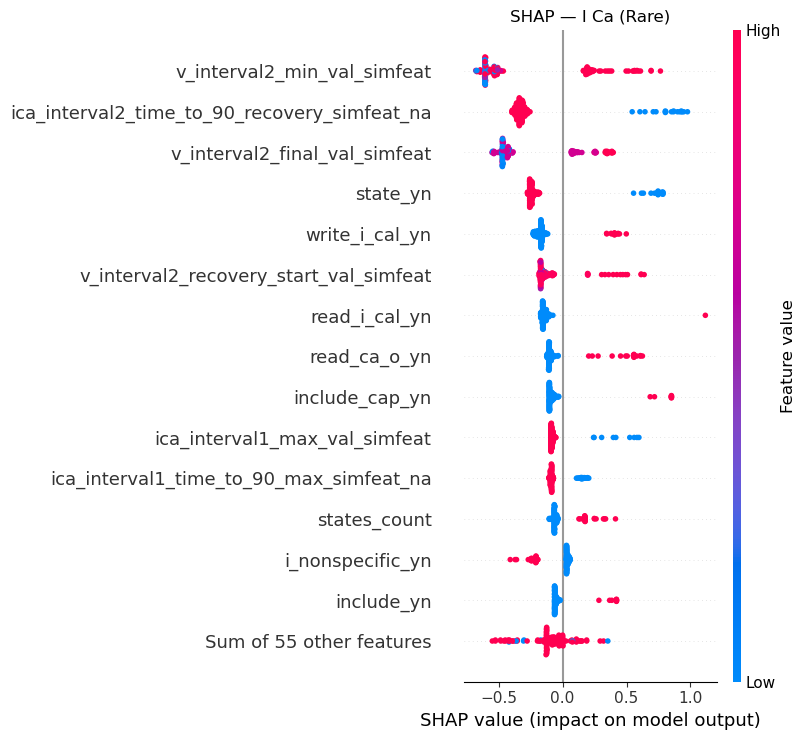

SHAP beeswarm — class 2: I Ca (T-type LT)


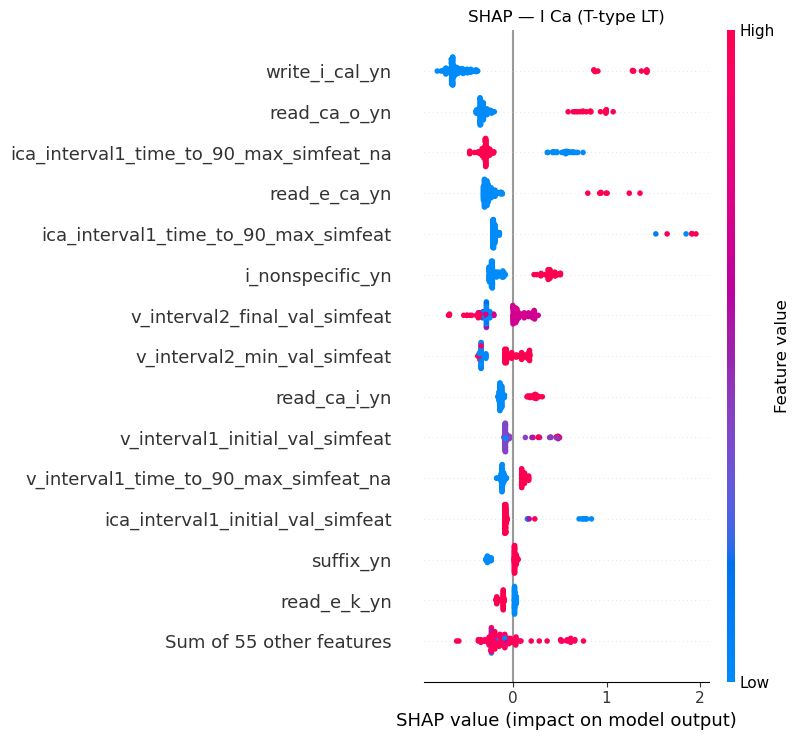

SHAP beeswarm — class 3: I H


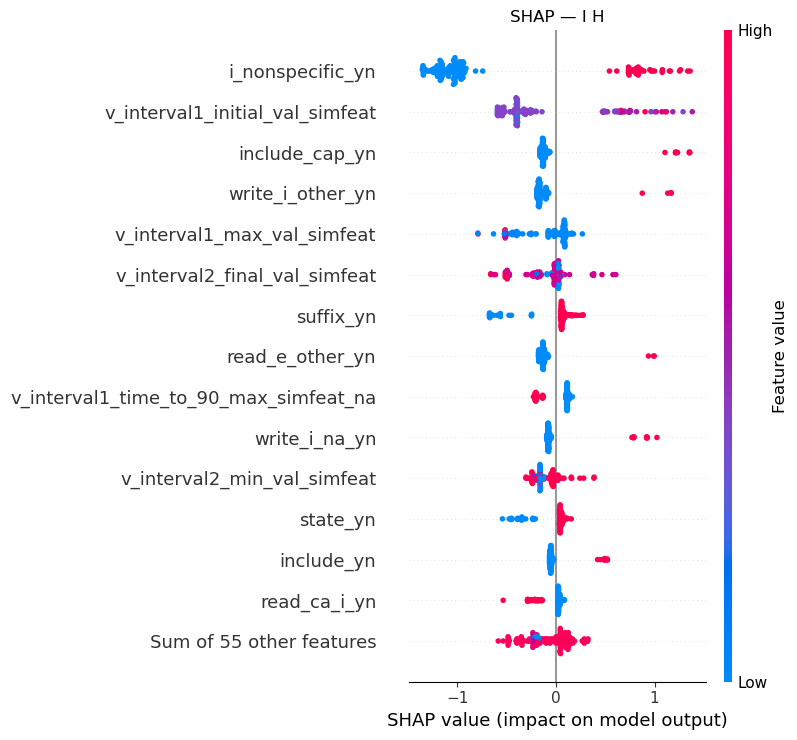

SHAP beeswarm — class 4: I K (A-type)


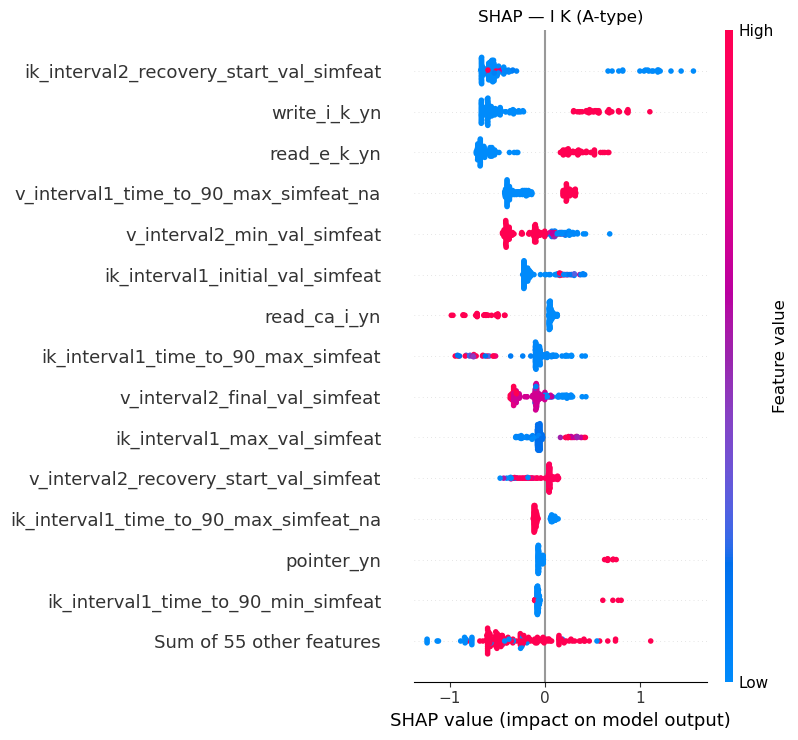

SHAP beeswarm — class 5: I K (Ca-activated)


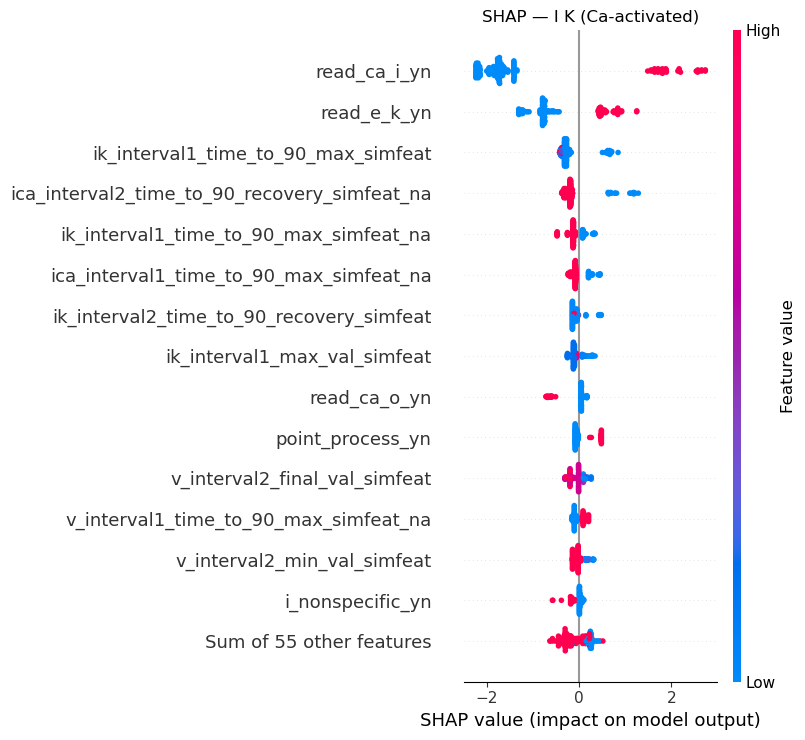

SHAP beeswarm — class 6: I K (Delayed Rectifier)


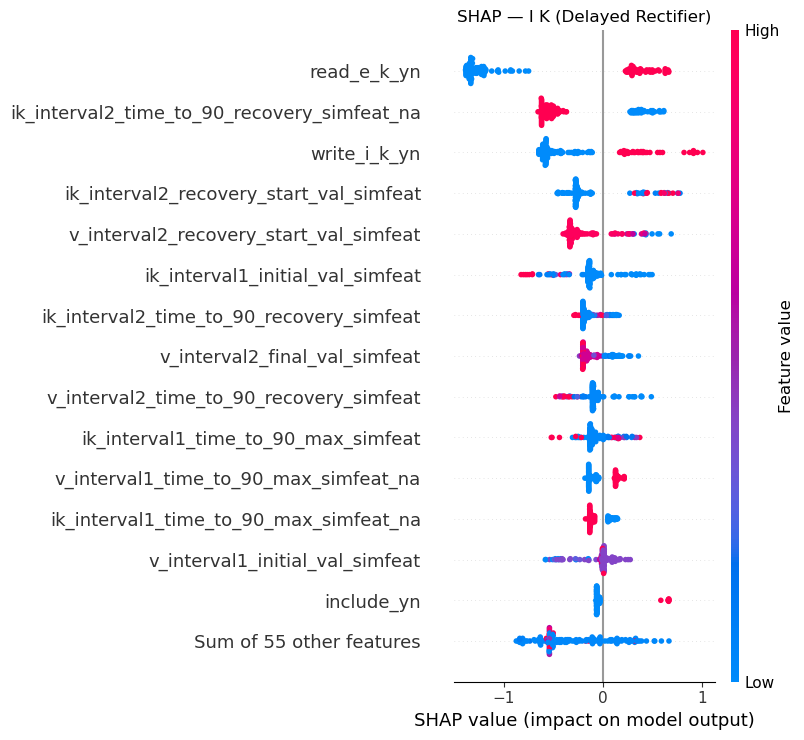

SHAP beeswarm — class 7: I K (M-type)


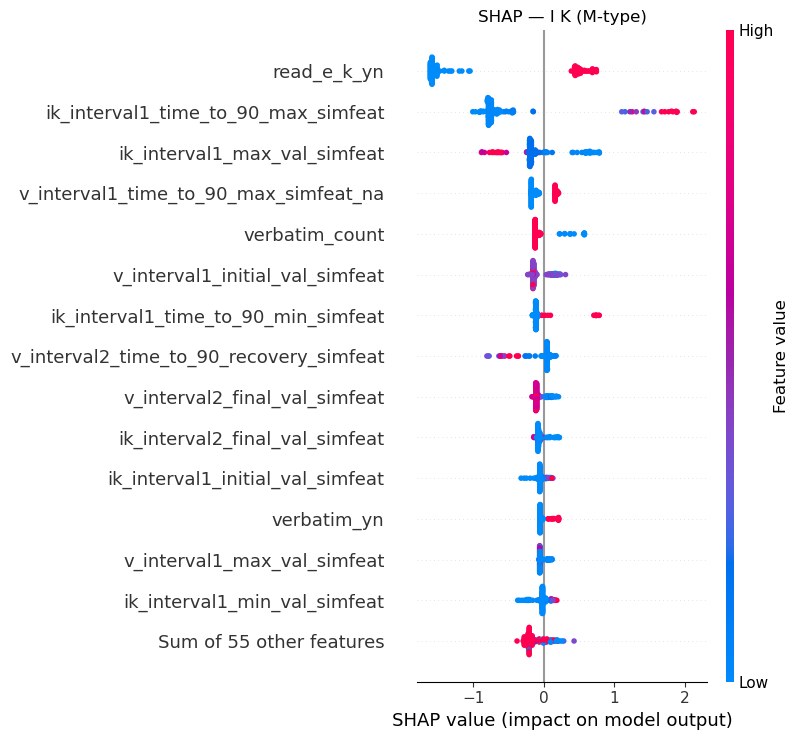

SHAP beeswarm — class 8: I K (Rare)


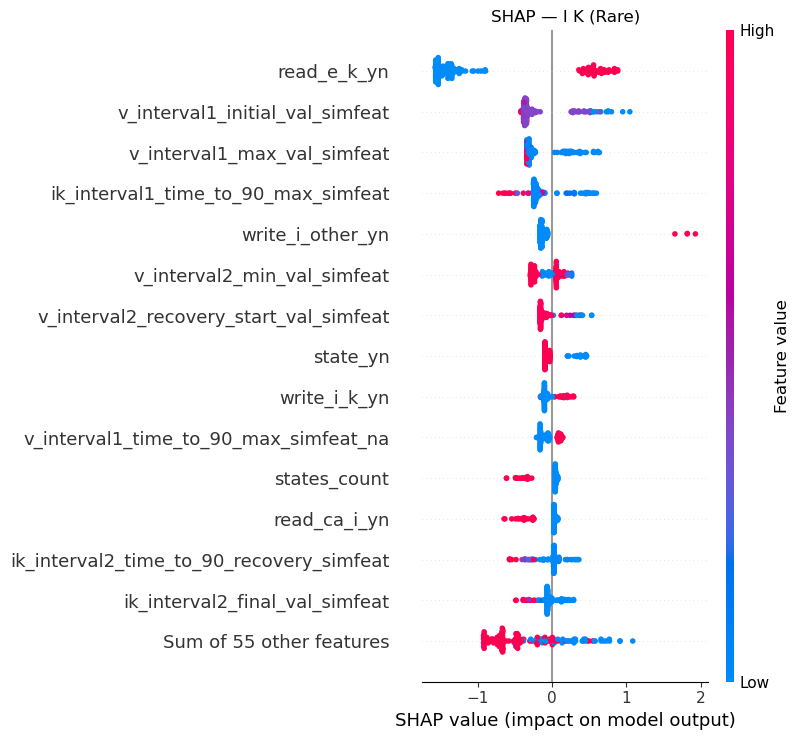

SHAP beeswarm — class 9: I Na (Persistent)


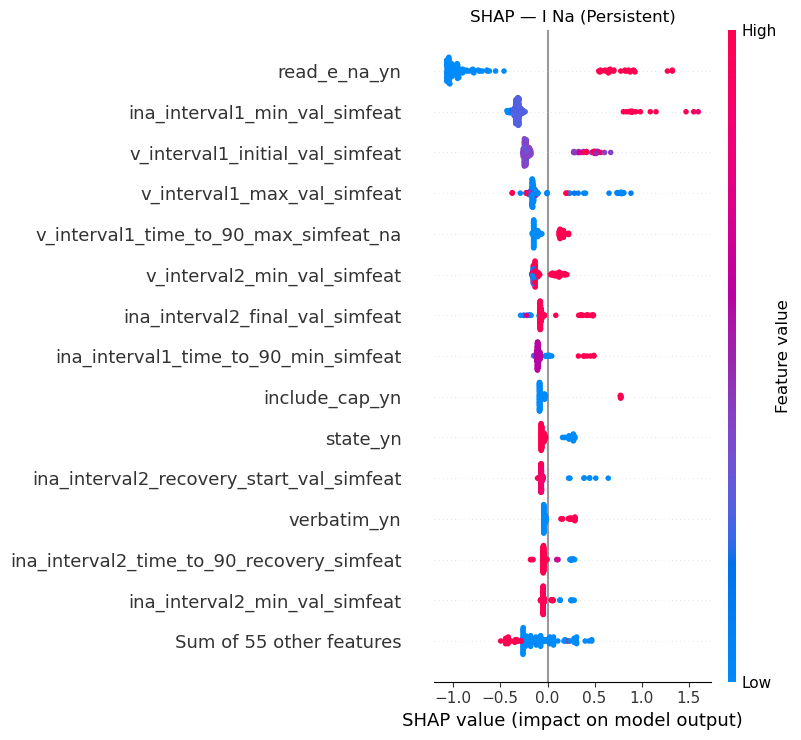

SHAP beeswarm — class 10: I Na (Rare)


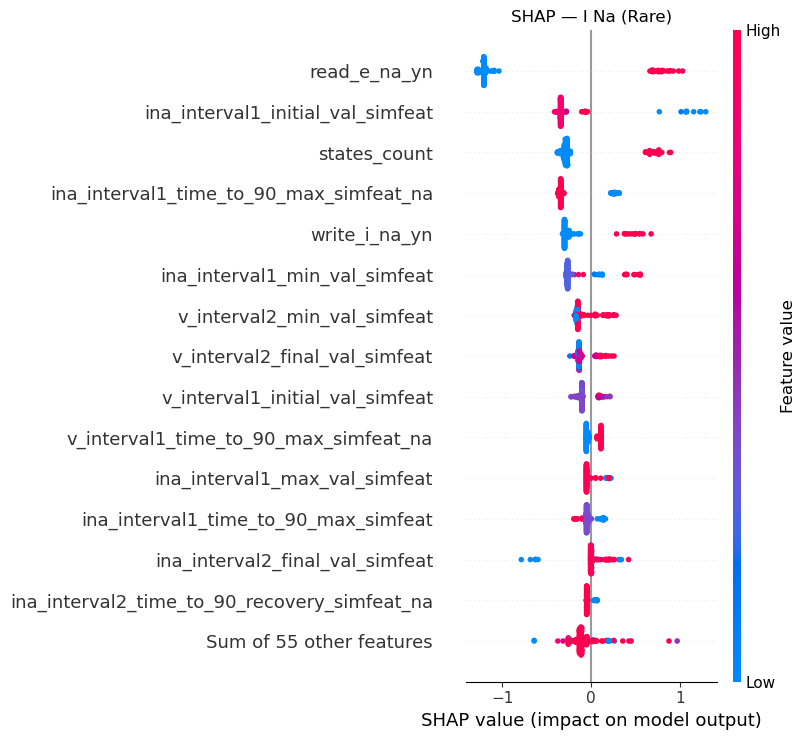

SHAP beeswarm — class 11: I Na (Slow inactivation)


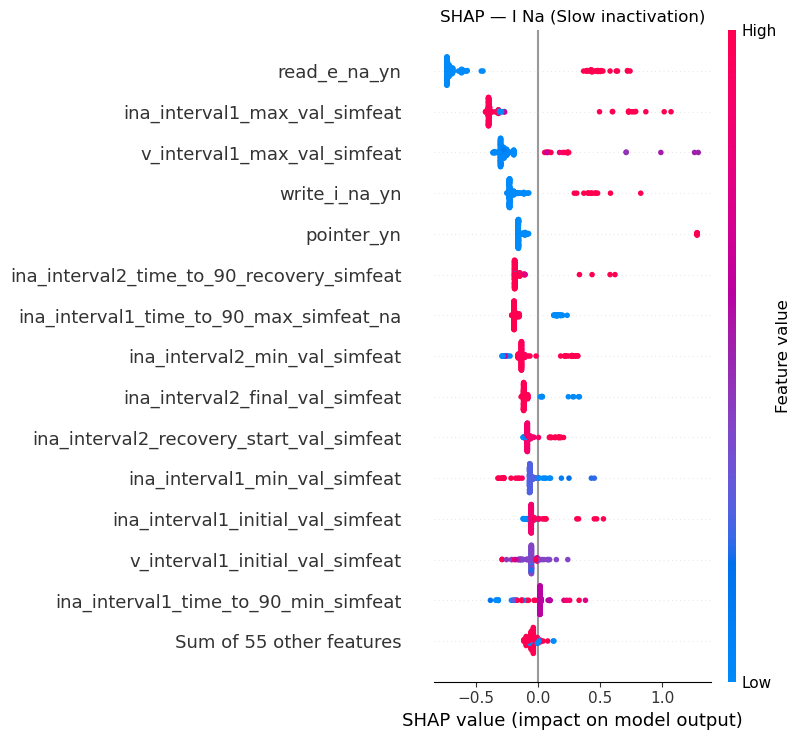

SHAP beeswarm — class 12: I Na (Transient)


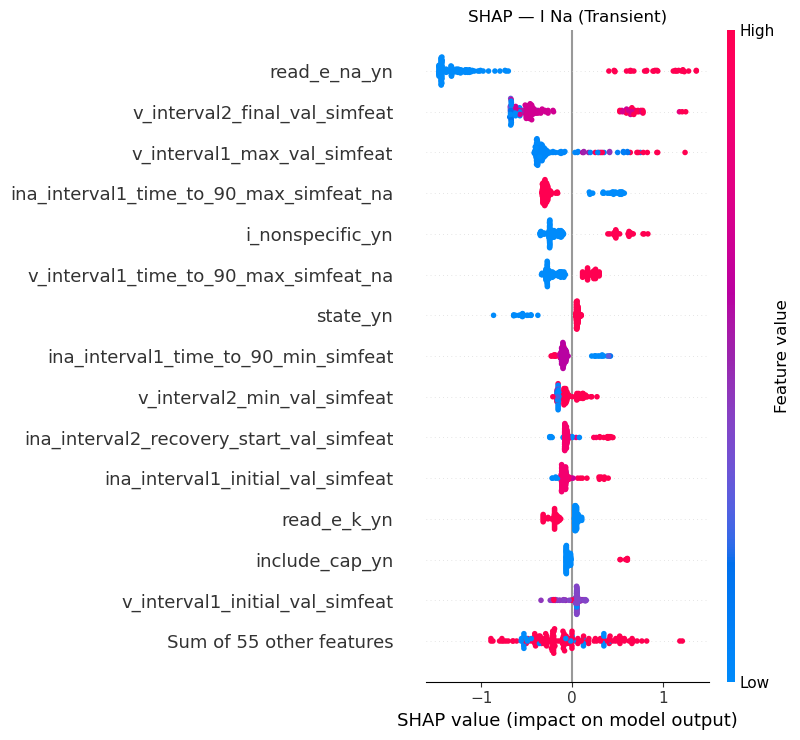

SHAP beeswarm — class 13: I Other (Rare)


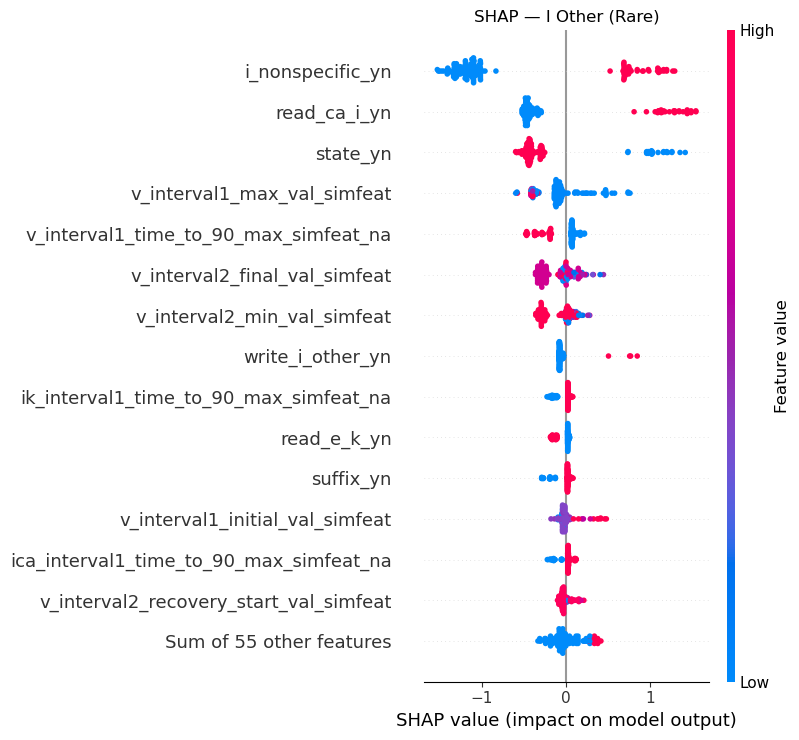

SHAP beeswarm — class 14: R GABA


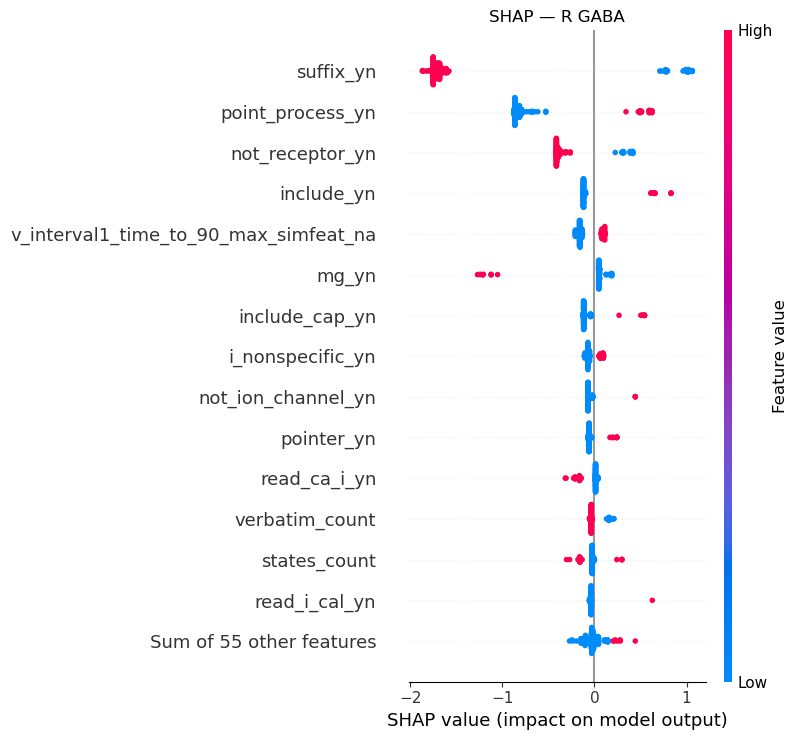

SHAP beeswarm — class 15: R Glutamate (AMPA)


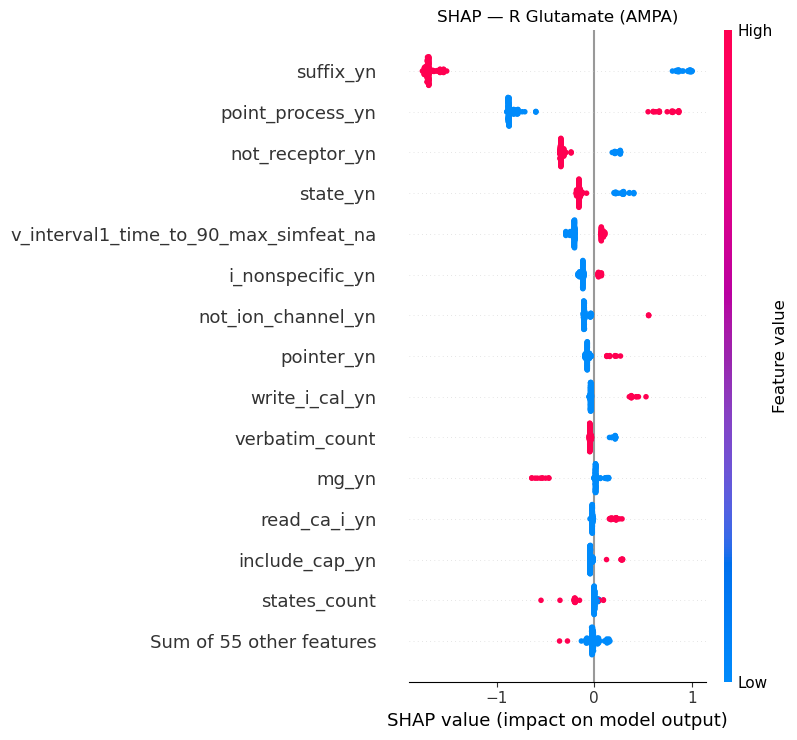

SHAP beeswarm — class 16: R Glutamate (NMDA)


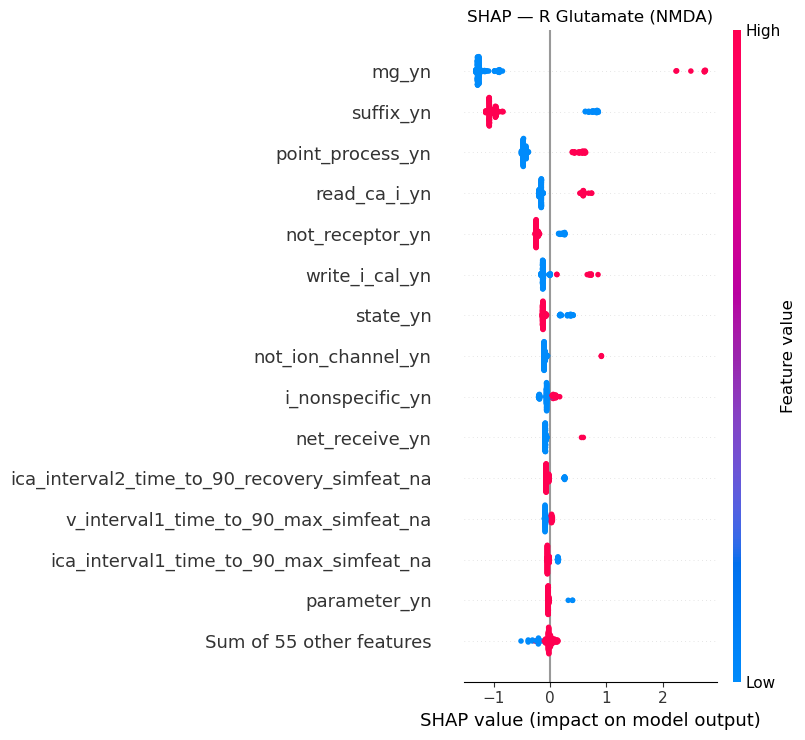

SHAP beeswarm — class 17: R Other (General)


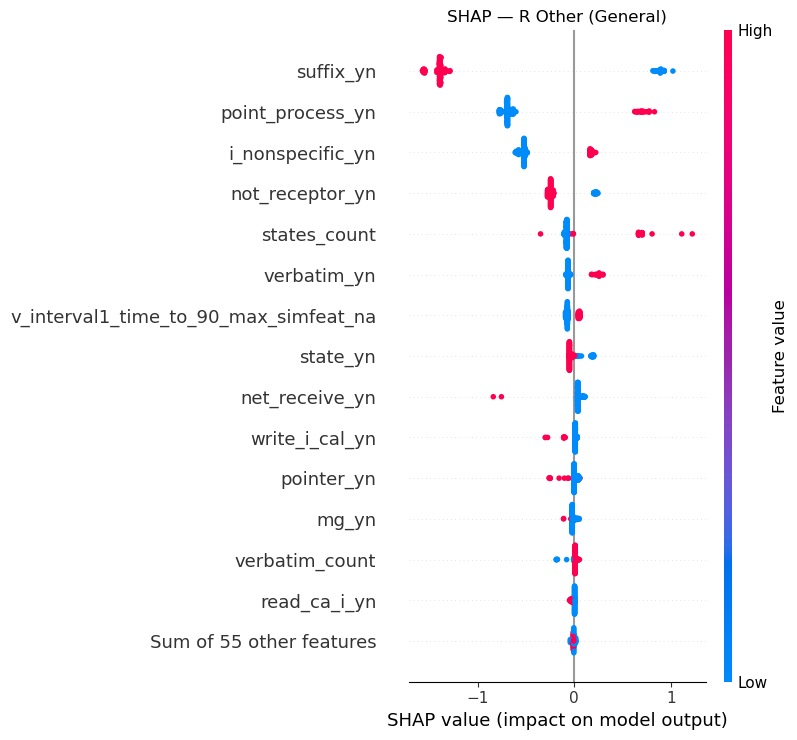

In [45]:
n_classes = shap_values_all.shape[2]
assert n_classes == len(subtype_encoder.classes_)

for class_idx, class_name in enumerate(subtype_encoder.classes_):
    print(f"SHAP beeswarm — class {class_idx}: {class_name}")

    shap.plots.beeswarm(
        shap_values_all[..., class_idx],
        max_display=15,
        show=False
    )

    plt.title(f"SHAP — {class_name}")
    plt.tight_layout()
    plt.show()

## Combining XGB and GPT predictions together

In [46]:
# === Build DataFrame with predictions and truth ===

# True values from test set
true_subtype = y_subtype_test  # string labels
true_type = y_type_test        # string labels

# Build dataframe using reverse model predictions
df_xgb_pred = pd.DataFrame({
    "file_hash": X_test_selected.index,  # or X_test_final.index if X_test_selected isn't defined
    "true_type": true_type.values,
    "true_subtype": true_subtype.values,
    "xgb_pred_type": y_type_pred_rev.values,
    "xgb_pred_subtype": y_subtype_pred_rev
})

# Add match flags
df_both = df_xgb_pred.merge(gpt_df, how="left", on="file_hash").rename(columns={"gpt_pred_type_label":"gpt_pred_type","gpt_pred_subtype_label":"gpt_pred_subtype"})



In [47]:

# Optional: add confidence for convenience in R
max_prob = proba.max(axis=1)                       # model confidence of predicted class
df_conf = pd.DataFrame({"file_hash": X_test_final.index, "xgb_pred_prob": max_prob})

# Merge into df_both (which already has truth/preds/match flags)
df_both = df_both.merge(df_shap, on="file_hash", how="left").merge(df_conf, on="file_hash", how="left")

# Export for R
df_both.to_csv("../data/pipeline/predictions_with_shap.csv", index=False)


# GPT performance

In [48]:


# --- helper: reusable confusion matrix plotter ---
def plot_confusion(y_true, y_pred, title, normalize=None, figsize=(10, 7)):
    # Collect labels present in either true or predicted
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=figsize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm_df, annot=True, fmt=fmt, cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ====== helpers ======
def _labels_from(*series_list):
    s = pd.concat([pd.Series(s) for s in series_list], ignore_index=True)
    return sorted(s.dropna().unique().tolist())

def plot_cm(ax, y_true, y_pred, labels, title, normalize=None, annot=True):
    if len(y_true) == 0:
        ax.axis('off')
        ax.text(0.5, 0.5, "No samples", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        return
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm, ax=ax, annot=annot, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=90)

In [49]:
#df_both.query("true_type == 'Neither' & xgb_pred_type != 'Neither'")

GPT Type Accuracy: 0.9036

GPT Type Classification Report:
              precision    recall  f1-score   support

        I Ca       0.81      1.00      0.89        25
         I H       1.00      1.00      1.00         9
         I K       0.94      0.99      0.96        68
        I Na       0.94      0.97      0.95        31
     I Other       0.00      0.00      0.00         7
     Neither       0.00      0.00      0.00         0
     R Other       0.00      0.00      0.00         0
    Receptor       0.95      0.73      0.83        26

    accuracy                           0.90       166
   macro avg       0.58      0.59      0.58       166
weighted avg       0.89      0.90      0.89       166



/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

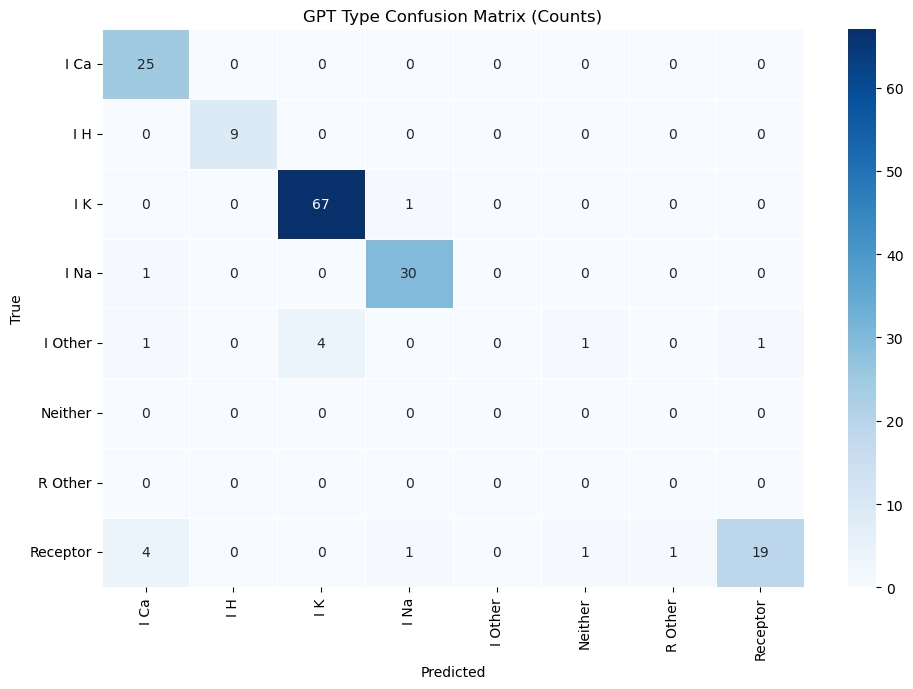

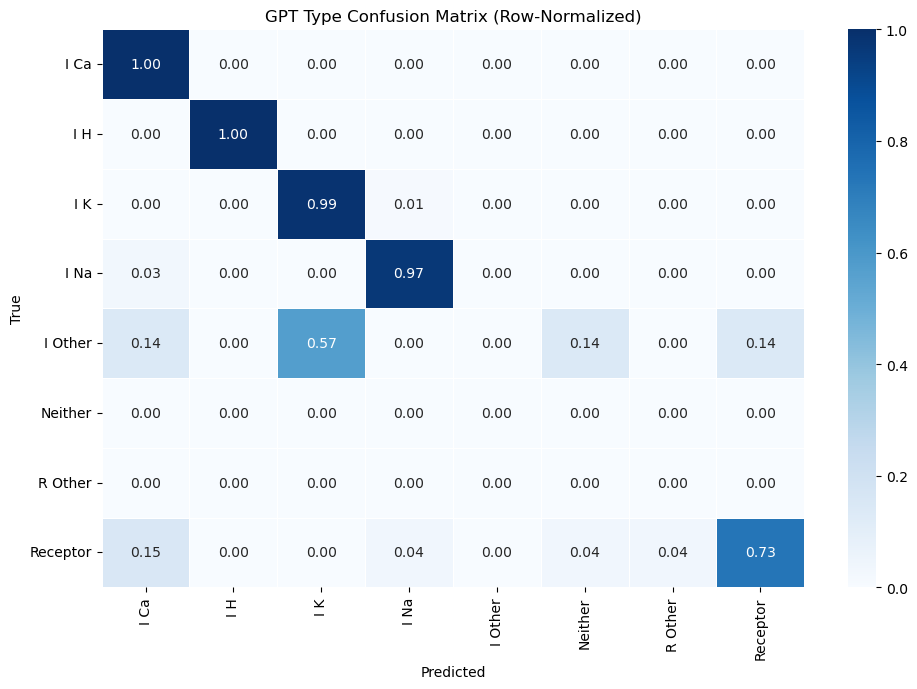


GPT Subtype Accuracy (Overall): 0.8012

GPT Subtype Classification Report (Overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.89      1.00      0.94        16
             I Ca (Rare)       0.29      0.67      0.40         3
        I Ca (T-type LT)       1.00      1.00      1.00         6
                     I H       1.00      1.00      1.00         9
            I K (A-type)       1.00      0.89      0.94        19
      I K (Ca-activated)       1.00      0.93      0.96        14
 I K (Delayed Rectifier)       0.92      0.65      0.76        17
            I K (M-type)       1.00      1.00      1.00         8
              I K (Rare)       0.43      0.90      0.58        10
       I Na (Persistent)       0.67      1.00      0.80         4
             I Na (Rare)       0.50      0.40      0.44         5
I Na (Slow inactivation)       1.00      0.50      0.67         4
        I Na (Transient)       0.85      0.94      0.89

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

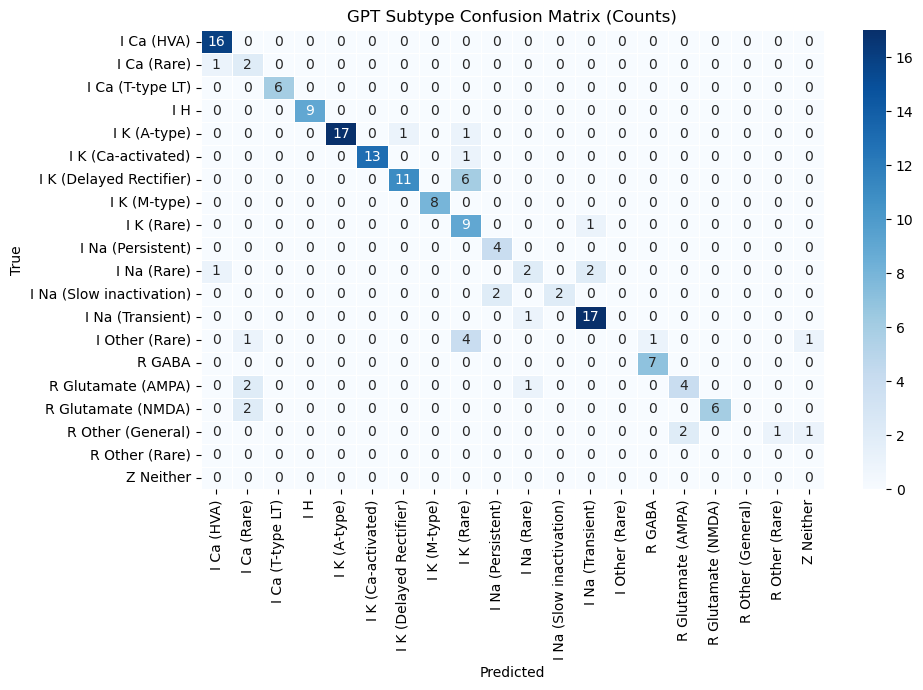

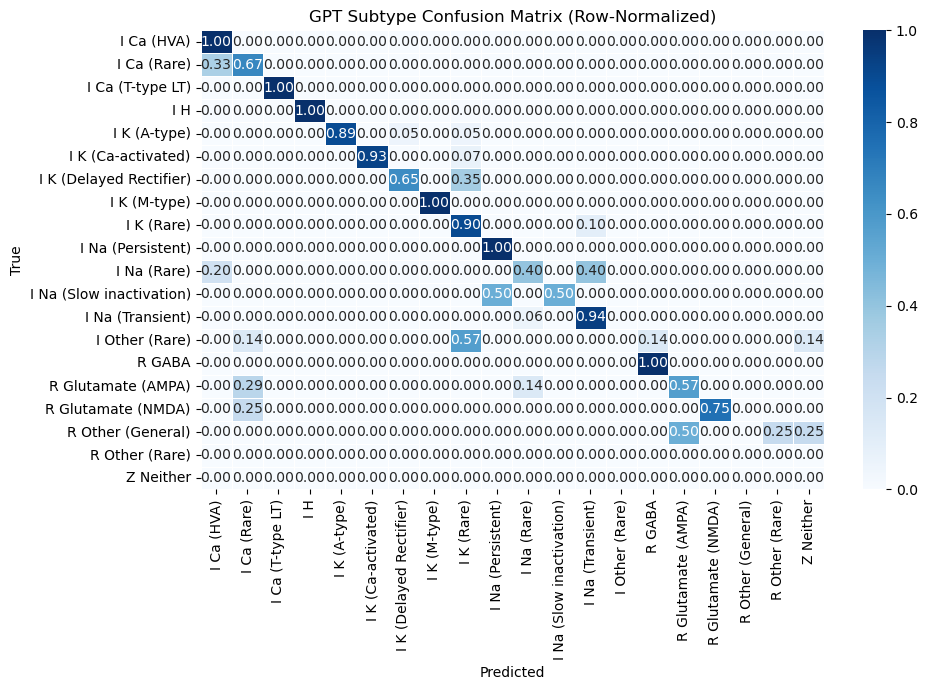

In [50]:


# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(df_both["true_type"], df_both["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    df_both["true_type"],
    df_both["gpt_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    df_both["true_type"],
    df_both["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    df_both["true_type"],
    df_both["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    df_both["true_subtype"], df_both["gpt_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    df_both["true_subtype"],
    df_both["gpt_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    df_both["true_subtype"],
    df_both["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    df_both["true_subtype"],
    df_both["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)


# Merging them

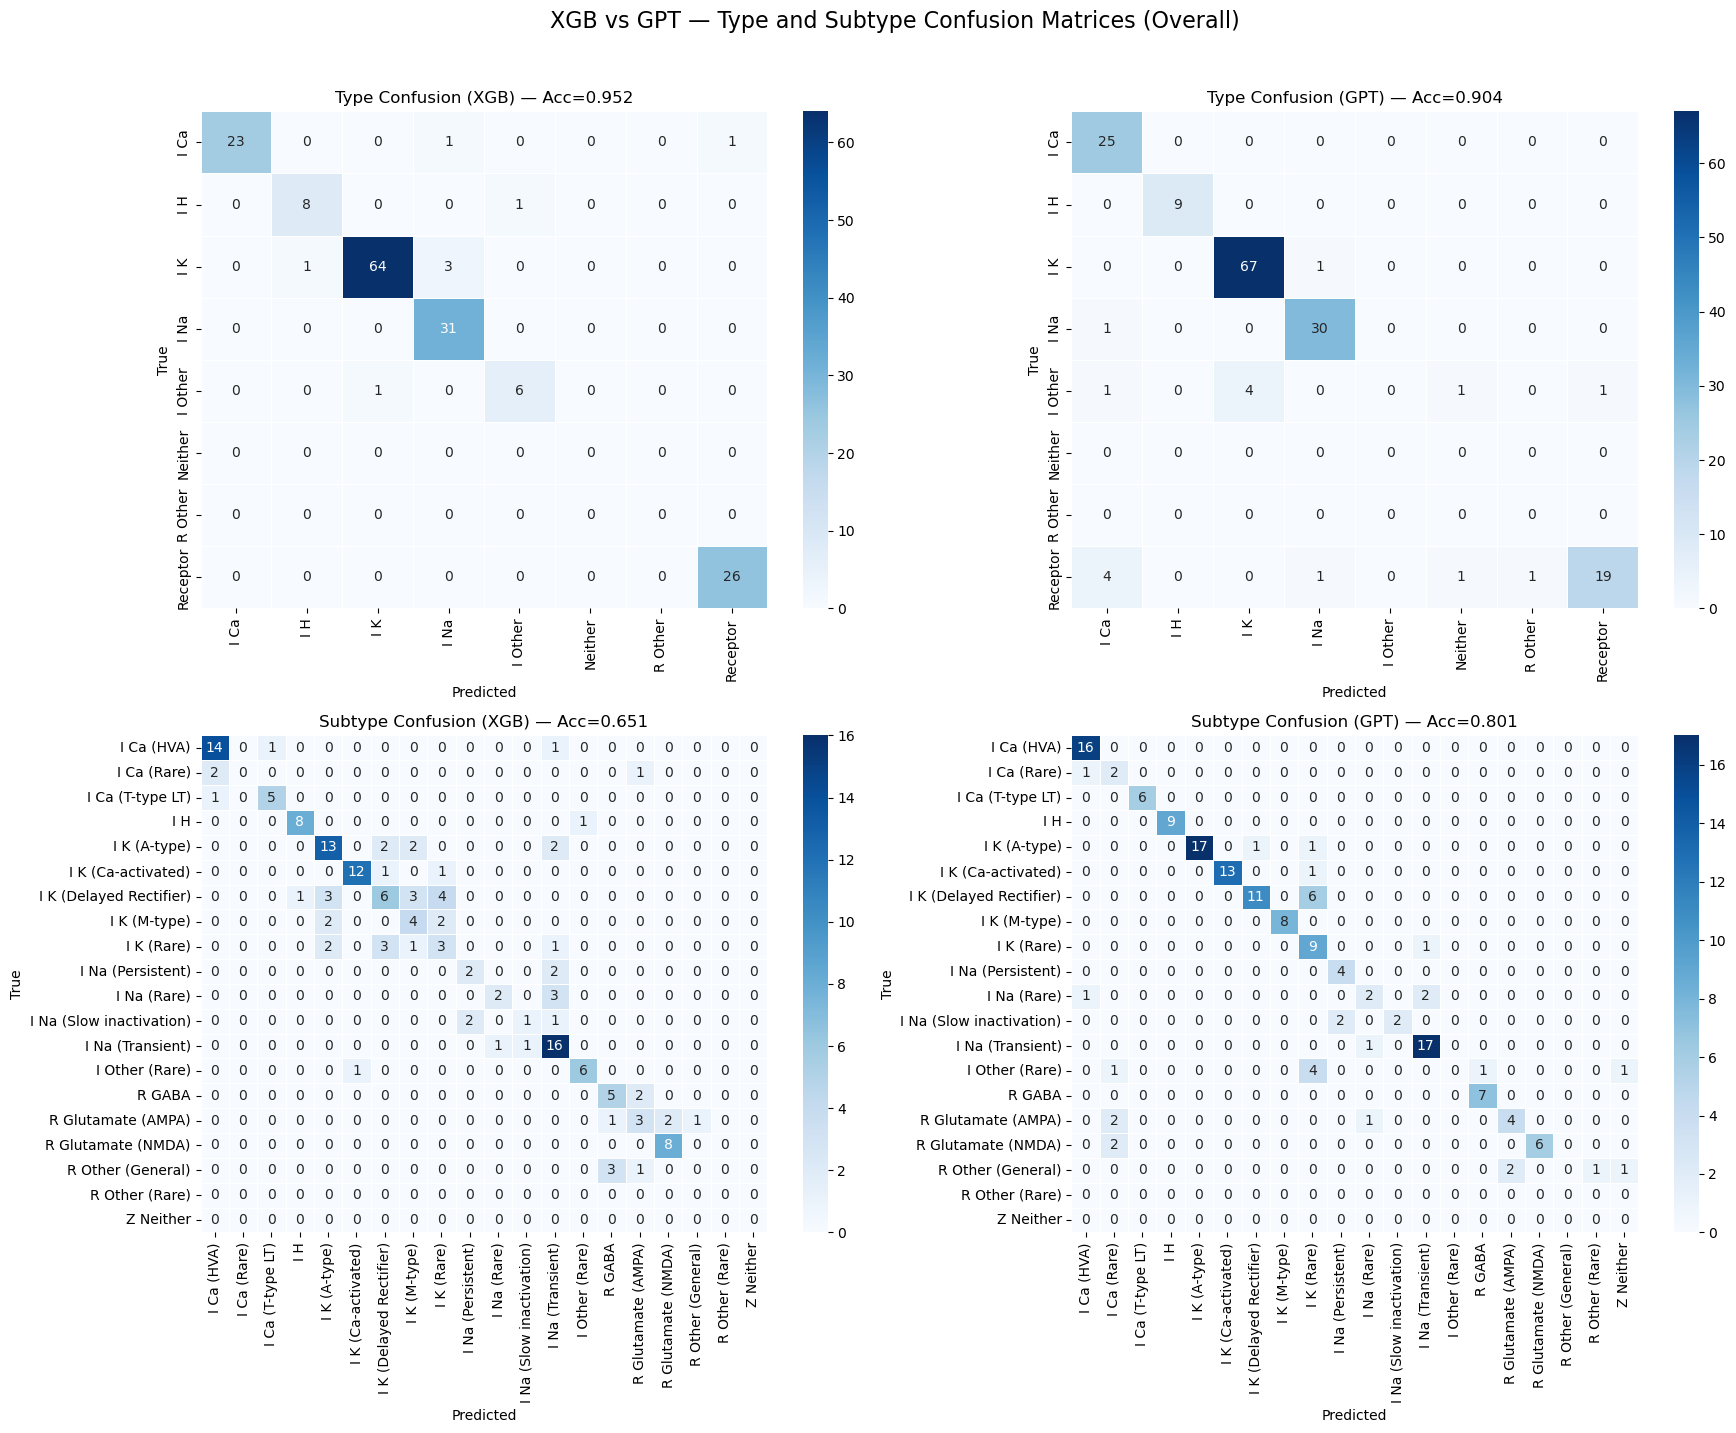

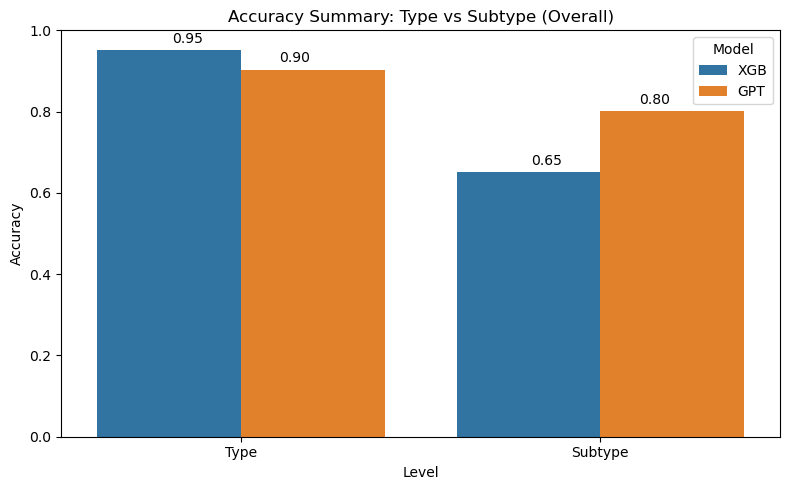

In [51]:
# ====== assemble labels ======
type_labels = _labels_from(
    df_both["true_type"], 
    df_both["gpt_pred_type"], 
    df_both["xgb_pred_type"]
)
subtype_labels = _labels_from(
    df_both["true_subtype"], 
    df_both["gpt_pred_subtype"], 
    df_both["xgb_pred_subtype"]
)

# ====== accuracies ======
acc_type_gpt = accuracy_score(df_both["true_type"], df_both["gpt_pred_type"])
acc_type_xgb = accuracy_score(df_both["true_type"], df_both["xgb_pred_type"])

acc_sub_gpt = accuracy_score(df_both["true_subtype"], df_both["gpt_pred_subtype"])
acc_sub_xgb = accuracy_score(df_both["true_subtype"], df_both["xgb_pred_subtype"])

# ====== 2x2 confusion matrices: Type (XGB/GPT) + Subtype (XGB/GPT) ======
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Type — XGB left, GPT right
plot_cm(
    axes[0, 0],
    df_both["true_type"], df_both["xgb_pred_type"], type_labels,
    title=f"Type Confusion (XGB) — Acc={acc_type_xgb:.3f}"
)
plot_cm(
    axes[0, 1],
    df_both["true_type"], df_both["gpt_pred_type"], type_labels,
    title=f"Type Confusion (GPT) — Acc={acc_type_gpt:.3f}"
)

# Subtype — XGB left, GPT right (no conditioning)
plot_cm(
    axes[1, 0],
    df_both["true_subtype"], df_both["xgb_pred_subtype"], subtype_labels,
    title=f"Subtype Confusion (XGB) — Acc={acc_sub_xgb:.3f}"
)
plot_cm(
    axes[1, 1],
    df_both["true_subtype"], df_both["gpt_pred_subtype"], subtype_labels,
    title=f"Subtype Confusion (GPT) — Acc={acc_sub_gpt:.3f}"
)

fig.suptitle("XGB vs GPT — Type and Subtype Confusion Matrices (Overall)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ====== Summary accuracy bar chart ======
acc_df = pd.DataFrame({
    "Model": ["XGB", "GPT", "XGB", "GPT"],
    "Level": ["Type", "Type", "Subtype", "Subtype"],
    "Accuracy": [acc_type_xgb, acc_type_gpt, acc_sub_xgb, acc_sub_gpt]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=acc_df, x="Level", y="Accuracy", hue="Model", hue_order=["XGB", "GPT"])
plt.ylim(0, 1)
plt.title("Accuracy Summary: Type vs Subtype (Overall)")
for i, v in enumerate(acc_df["Accuracy"]):
    plt.text(x=i//2 + (-0.15 if i % 2 == 0 else 0.15),
             y=min(0.98, (0 if np.isnan(v) else v)) + 0.01,
             s=("NA" if np.isnan(v) else f"{v:.2f}"),
             ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


In [52]:
#76.9,74.4